# Tutorial on Sea Surface Temperature (SST) and Sea Ice Surface Temperature (IST) using Climate Data from C3S

### About

In this tutorial we will access data from the Climate Data Store (CDS) of the Copernicus Climate Change Service (C3S), and analyse climatologies and trends in polar sea, sea-ice and icecap surface temperatures. The data is derived from satellite observations north of 50°N and south of 50°S. The data used for this tutorial can be found on the Copernicus Climate Data Store and is called "Sea ice surface temperature derived from satellite observations". The data page and documentation can also be found with the following link: https://doi.org/10.24381/4e222208

The Climate Data Record (CDR) covers the period 1982-June 2019 and is extended through the Interim Climate Data Record (ICDR) for July 2019-Now. The data is updated monthly with a latency period of up to 14 days. 
Examples of filenames are for the CDR: YYYYMMDD000000-DMI_MET-L3S_GHRSST-STskin-AVHRR_nh_SST_IST-CDR-v1.0-fv1.0.nc and for the ICDR: YYYYMMDD000000-DMI_MET-L3S_GHRSST-STskin-AVHRR_sh_SST_IST-ICDR-v1.1-fv1.0.nc, where YYYY is the year, MM is the month and DD is the day. The *nh* and *sh* respectively denotes the northern and southern hemispheres. There are two daily files, one for *nh* and one for *sh*.

The tutorial consists of the following steps:

1. Search, download and view data
2. Calculate a climatology of surface temperatures for the period 1991-2020 (Requires a lot of local/server storage os where to save the data once downloaded from the CDS)
3. Compute and visualise anomalies of a chosen year (2025) with respect to the climate normal (again, Requires a lot of local/server storage os where to save the data once downloaded from the CDS)

## 1. Search, download and view data

Before we begin we must prepare our environment. This includes installing the Application Programming Interface (API) of the CDS, and importing the various python libraries that we will need.

#### Install CDS API

To install the CDS API, run the following command. We use an exclamation mark to pass the command to the shell (not to the Python interpreter).

In [1]:
!pip install cdsapi
# shall be "cdsapi>=0.7.7"

#### Import libraries

We will be working with data in NetCDF format. To best handle this data we will use libraries for working with multidimensional arrays, in particular Xarray. We will also need libraries for plotting and viewing data, in this case we will use Matplotlib and Cartopy. Lastly we need the scipy package to compute basic statistics.

In [ ]:
# Packages
# CDS API

import os
import glob
import sys
from datetime import datetime
import numpy as np
from scipy import stats
import dask
import xarray as xr
from fnmatch import fnmatch
import matplotlib.pyplot as plt
from cartopy import crs as ccrs
import cartopy.feature as cfeature
from zipfile import ZipFile
from dateutil.relativedelta import relativedelta
import math
import cdsapi

#### Setting your CDS API key

We will request data from the Climate Data Store (CDS) programmatically with the help of the CDS API. For that we need API credentials.  There are 2 ways to set the CDS API credentials, setting directly in the code or setting the credentials locally on your computer.  
First, you have to define two variables: `URL` and `KEY` which build together your CDS API key. The string of characters that make up your KEY include your personal User ID and CDS API key. To obtain these, first register or login to the CDS (https://cds.climate.copernicus.eu), then visit https://cds.climate.copernicus.eu/how-to-api. From there you copy the key and url strings to a code cell (as out-commented in the next code cell) __or__ to your ~/.cdsapirc file in your home directory:  
__url: https://cds.climate.copernicus.eu/api__  
__key: < ---- YOUR CDSAPI KEY ---- >__

In [7]:
# Make sure following 2 lines (url and key) are in your ~/.cdsapirc file
# url: https://cds.climate.copernicus.eu/api
# key: < ---- YOUR CDSAPI KEY ---- >

Now we will specify a data directory in which we will download our data and all output files that we will generate:

In [ ]:
BASEPATH = <'define_your_basepath'>                     # This is the base directory of your analysis
# BASEPATH = '/dmidata/users/gd/c3s_ur_testdata'        #USED FOR TEST BY PRODUCER
DATADIR = f'{BASEPATH}/data'                            # This is the directory where the downloaded data will be located
DAILY_DATADIR = DATADIR + '/' + "daily"
CLIM_DATADIR = DATADIR + '/' + "clim"
path_out = f'{BASEPATH}/figures' #This is the directory where the output figures will be saved
target_file = f'{DATADIR}/daily/temp.zip' #This is the path to the zip file containing the downloaded data. Remember to change this name if you repeatedly downloaded the data and have multiple zip files. You can also change the name of the zip file to something more descriptive. If the filename is not changed, previous downloads will be overwritten.
if not os.path.exists(DATADIR):os.makedirs(DATADIR)
if not os.path.exists(f'{DATADIR}/daily/'):os.makedirs(f'{DATADIR}/daily/')
if not os.path.exists(f'{DATADIR}/clim/'):os.makedirs(f'{DATADIR}/clim/')
if not os.path.exists(path_out):os.makedirs(path_out)
os.chdir(f'{DATADIR}/daily')


Now we specify some information needed for the data download from the Copernicus data store (CDS).

In [4]:
dataset = "satellite-ist-sst-polar"

hem = "nh" # "nh" or "sh"
if hem == "nh":
    hemisphere = "northern_hemisphere"
elif hem == "sh":
    hemisphere = "southern_hemisphere"

#### Search for data

To search for data, visit the CDS website: http://cds.climate.copernicus.eu.
Here you can search for SST and IST data using the search bar (or DMI as the data provider, or similar). The data we need for this tutorial is the L3 polar SST/IST Climate Data Record which can be found by going to the URL "https://cds.climate.copernicus.eu/datasets/satellite-ist-sst-polar?tab=overview" or "https://doi.org/10.24381/4e222208". The data can also be found by searching for "Sea ice surface temperature derived from satellite observations", but this might also result in other similar datasets. 
The dataset name in the api-requst is: `satellite-ist-sst-polar` so this can also be searched for in the search bar.

Having selected the correct dataset, we now need to specify what product type, variables, temporal and geographic coverage we are interested in. You can get an overview of the possible selections in the **Download** tab. 
In this tab a form appears in which we will select the following parameters to download:

- Variable: `All` #ATM we can only get all possible variables
- Region: `Northern Hemisphere` # Northern or Southern hemisphere or both if you want to get north of 50° as well as south of -50° latitude.
- Temporal aggregation: `Daily` # Daily or Monthly - be aware that this choice is exclusive, meaning that you have to make two requests if you want the data in both **daily** and **monthly** temporal resolution.
- Year: `2025` # Any year in the coverage period; 1982-Now
- Month: `["01", "02", "03","04", "05", "06", "07", "08", "09", "10", "11", "12"]` #Any month or all to get full year
- Day: `["01", "02", "03", "04", "05", "06", "07", "08", "09", "10", "11", "12", "13", "14", "15", "16", "17", "18", "19", "20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31"]` #Any day or all to get full month/year
- Version: `1_1` #Version 1_0 is the CDR only (January 1st 1982 - June 30th 2019). Version 1_1 is the ICDR only (July 1st 2019 - Now). Chose both for full availability

At the end of the download form, select **"Show API request code"**. This will reveal a block of code, which you can simply copy and paste into a cell of your Jupyter Notebook (see cell below) ...

#### Download data

... having copied the API request into the cell below, running this will retrieve and download the data you requested into your local directory. However, before you run the cell below, the **terms of use** of this particular dataset need to have been accepted in the CDS. The option to view and accept these conditions is given at the end of the download form, just above the **"Show API request"** option.

If you simply want to get to know this data you can also leave the API request as is in the cell below, to use a prechosen example.
The first shown example of the API request (called **request1**) will download EVERYTHING there is (be aware that this is a lot of data and might not even be feasible to download using this method), but it is a good way to show all options.

The second shown example of the API request (called **request2**)  is showing how to simply download a single year (2025) of data for the chosen hemisphere and working with that.

The third shown example of the API request (called **request3**)  is showing how to simply download a few days of data for the chosen hemisphere and working with that. Due to the massive amount of data in example 1 and 2, we will use the data downloaded with example 3 for the remainder of this tutorial.

In [ ]:
# EXAMPLES OF DATA REQUESTS

request1 = {
    "variable": "all",
    "region": ["northern_hemisphere","southern_hemisphere"],
    "temporal_aggregation": "daily",
    "year": [
        "1982", "1983", "1984", 
        "1985", "1986", "1987",
        "1988", "1989", "1990", 
        "1991", "1992", "1993",
        "1994", "1995", "1996", 
        "1997", "1998", "1999", 
        "2000", "2001", "2002", 
        "2003", "2004", "2005", 
        "2006", "2007", "2008", 
        "2009", "2010", "2011", 
        "2012", "2013", "2014", 
        "2015", "2016", "2017", 
        "2018", "2019", "2020", 
        "2021", "2022", "2023",
        "2024", "2025", "2026"],
    "month": [  
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12"],
    "day": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12",
        "13", "14", "15",
        "16", "17", "18",
        "19", "20", "21",
        "22", "23", "24",
        "25", "26", "27",
        "28", "29", "30",
        "31"],
    "version": ["1_0","1_1"]
}

request2 = {
    "variable": "all",
    "region": [hemisphere],
    "temporal_aggregation": "daily",
    "year": ["2025"],
    "month": [  
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12"],
    "day": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12",
        "13", "14", "15",
        "16", "17", "18",
        "19", "20", "21",
        "22", "23", "24",
        "25", "26", "27",
        "28", "29", "30",
        "31"],
    "version": ["1_0"]
}

request3 = {
    "variable": "all",
    "region": [hemisphere],
    "temporal_aggregation": "daily",
    "year": ["2025"],
    "month": ["03"],
    "day": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12",
        "13", "14", "15",
        "16", "17", "18",
        "19", "20", "21",
        "22", "23", "24",
        "25", "26", "27",
        "28", "29", "30",
        "31"],
    "version": ["1_1"]
}

request4 = {
    "variable": "all",
    "region": [hemisphere],
    "temporal_aggregation": "daily",
    "year": ["2025"],
    "month": ["08"],
    "day": ["01", "02", "03","04", "05"],
    "version": ["1_1"]
}


client = cdsapi.Client()
client.retrieve(dataset, request3, target_file)

2026-08-17 09:17:18,797 INFO Request ID is 4f6c55be-ac2e-4bde-b2cb-5eaf135e1de0
2026-08-17 09:17:18,931 INFO status has been updated to accepted
2026-08-17 09:17:52,492 INFO status has been updated to running
2026-08-17 09:19:13,976 INFO status has been updated to successful


'/dmidata/users/gd/c3s_ur_testdata/data/daily/temp.zip'

#### Inspect data

Now that we have downloaded the data, we can inspect it. We have downloaded the data in a zip file containing the data in NetCDF format. This is a commonly used format for array-oriented scientific data. To read and process this data we will make use of the [Xarray](http://xarray.pydata.org/en/stable/) library. Xarray is an open source project and Python package that makes working with labelled multi-dimensional arrays simple and efficient. We will read the data from our NetCDF file into an [xarray.Dataset](https://xarray.pydata.org/en/stable/generated/xarray.Dataset.html).

First we need to unpack the zip file containing the data. The downloaded zip file is located in the [DATADIR] we defined above.

In [6]:
# loading the temp.zip and creating a zip object
with ZipFile(f"{target_file}", 'r') as zObject:
    # Extracting all the members of the zip into a specific location.
    zObject.extractall(
        path=f"{DATADIR}/daily/")

Now let's display the data from a given day

In [7]:
# load data
files = np.sort(glob.glob(f'{DATADIR}/daily/*{hem}*.nc'))
try:
    ds = xr.open_mfdataset(files,combine="nested",concat_dim="time")
except:
    ds = xr.open_mfdataset(files,combine="by_coords")
print(ds)

/tmp/ipykernel_63846/3897672174.py:4: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time_3hrly' ('time_3hrly',) The recommendation is to set join explicitly for this case.
  ds = xr.open_mfdataset(files,combine="nested",concat_dim="time")


<xarray.Dataset> Size: 15GB
Dimensions:                              (time: 31, lat: 160, lon: 1440,
                                          time_3hrly: 248)
Coordinates:
  * time                                 (time) float64 248B 1.741e+15 ... 1....
  * lat                                  (lat) float32 640B 50.12 ... 89.88
  * lon                                  (lon) float32 6kB -179.9 ... 179.9
  * time_3hrly                           (time_3hrly) float64 2kB 1.741e+15 ....
Data variables: (12/14)
    surface_temperature                  (time, lat, lon) float32 29MB dask.array<chunksize=(1, 160, 1440), meta=np.ndarray>
    surface_temperature_std              (time, lat, lon) float32 29MB dask.array<chunksize=(1, 160, 1440), meta=np.ndarray>
    surface_temperature_min              (time, lat, lon) float32 29MB dask.array<chunksize=(1, 160, 1440), meta=np.ndarray>
    surface_temperature_max              (time, lat, lon) float32 29MB dask.array<chunksize=(1, 160, 1440), meta=n

/tmp/ipykernel_63846/3897672174.py:4: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(files,combine="nested",concat_dim="time")


In [8]:
# Read data
ST = ds['surface_temperature'].squeeze()  # surface temperature (SST/IST) in Kelvin
mask = ds['land_mask'] # Land, ocean, icecap, seaice mask
lon = ds['lon'] # longitude
lat = ds['lat'] # lattitude

Let's display the sea and sea ice surface temperature dataarray and make sure to take a look at the time bonds of the downloaded data.

In [ ]:
print(f"ST: {ST}")
print(f"Time: {ST.time}")   # TIMES ARE IN MICRO-SECONDS SINCE EPOC

ST: <xarray.DataArray 'surface_temperature' (time: 31, lat: 160, lon: 1440)> Size: 29MB
dask.array<concatenate, shape=(31, 160, 1440), dtype=float32, chunksize=(1, 160, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) float64 248B 1.741e+15 1.741e+15 ... 1.743e+15 1.743e+15
  * lat      (lat) float32 640B 50.12 50.38 50.62 50.88 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
Attributes:
    units:      K
    long_name:  Daily mean of sea and ice surface temperature
Time: <xarray.DataArray 'time' (time: 31)> Size: 248B
array([1.740787e+15, 1.740874e+15, 1.740960e+15, 1.741046e+15, 1.741133e+15,
       1.741219e+15, 1.741306e+15, 1.741392e+15, 1.741478e+15, 1.741565e+15,
       1.741651e+15, 1.741738e+15, 1.741824e+15, 1.741910e+15, 1.741997e+15,
       1.742083e+15, 1.742170e+15, 1.742256e+15, 1.742342e+15, 1.742429e+15,
       1.742515e+15, 1.742602e+15, 1.742688e+15, 1.742774e+15, 1.742861e+15,
       1.742947e+15

#### Change temperature units from Kelvin to Celsius

Notice that the sea surface temperatures and the sea and sea ice surface temperatures are in units of `Kelvin`, the base unit for temperature in the International System of Units (SI). If you want to convert the values from `Kelvin` to `degrees Celsius`, you have to subtract 273.15.

In [10]:
ST_degc =  ST - 273.15

**Simple visualisation and statistics**

For a simple vizualisation of the data one can use the script below which creates a simple geographical representation of the data using cartopy


In [ ]:
def geographical_simple(data, varname, path_out, date, hem, savename):
    # make simple geographical plot
    if hem == 'nh': #ds.lat.min() > 0:
        fig, ax = plt.subplots(nrows=1,ncols=1, subplot_kw={'projection': ccrs.NorthPolarStereo()}, figsize=(15,8))
        extent=[-180, 180, 50, 90]
    else:
        fig, ax = plt.subplots(nrows=1,ncols=1, subplot_kw={'projection': ccrs.SouthPolarStereo()}, figsize=(15,8))
        extent=[-180, 180, -90, -50]
    
    ax.set_facecolor('none')  # Makes background transparent for circular effect
    ax.set_frame_on(False)
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    #ax.set_extent(extent, crs=ccrs.SouthPolarStereo())
    ax.add_feature(cfeature.LAND.with_scale('110m'), color='lightgray')
    ax.add_feature(cfeature.COASTLINE)
    # Add lat/lon gridlines
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.8,
        color='gray',
        alpha=0.7,
        linestyle='-'
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 10, 'weight': 'bold'}
    gl.ylabel_style = {'size': 10, 'weight': 'bold'}
    
    if varname.upper()=='ST':
        labelname = 'SST and IST'
        vmin = math.floor(np.nanmin(data)/5)*5 #-40
        vmax = math.ceil(np.nanmax(data)/5)*5 #35
    else:
        labelname=varname
        vmin=np.nanmin(data)
        vmax=np.nanmax(data)


    img = ax.imshow(
        np.flipud(data),
        cmap='viridis',
        vmin=vmin,
        vmax=vmax,
        interpolation='none',
        transform=ccrs.PlateCarree(),
        extent=extent,
    )

    label = f'{labelname} [°C]' if varname.upper() in ['ST'] else labelname
    cbar = plt.colorbar(img, ax=ax, orientation='vertical', label=label)

    ax.set_title(f'C3S {hem} L3 {labelname} for {date}')

    plt.savefig(f'{path_out}/{savename}', bbox_inches='tight')
    plt.show()
    
def basic_statistics(data, varname):
    print(f'##### BASIC STATISTICS FOR {varname} ######\n')

    mean_value = np.round(np.nanmean(data), 2).item()
    median_value = np.round(np.nanmedian(data), 2)
    std_dev = np.round(np.nanstd(data), 2)
    max_value = np.round(np.nanmax(data), 2)
    min_value = np.round(np.nanmin(data), 2)

    print(f'Mean value: {mean_value:.2f} \n')
    print(f'Median value: {median_value:.2f} \n')
    print(f'Standard deviation: {std_dev:.2f} \n')
    print(f'Maximum value: {max_value:.2f} \n')
    print(f'Minimum value: {min_value:.2f} \n')

Let's make a geographical plot for a specific date and compute basic statistics for the landmask, along with the Sea and Sea-ice Surface temperature variable. Change the date if you want to see other dates plotted.

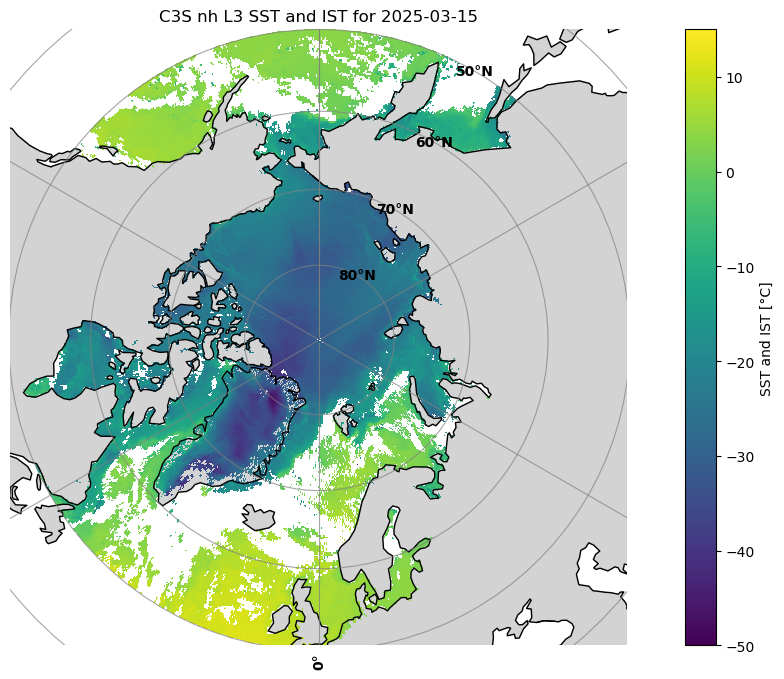

##### BASIC STATISTICS FOR ST ######

Mean value: -21.54 

Median value: -26.43 

Standard deviation: 12.92 

Maximum value: 12.19 

Minimum value: -47.46 



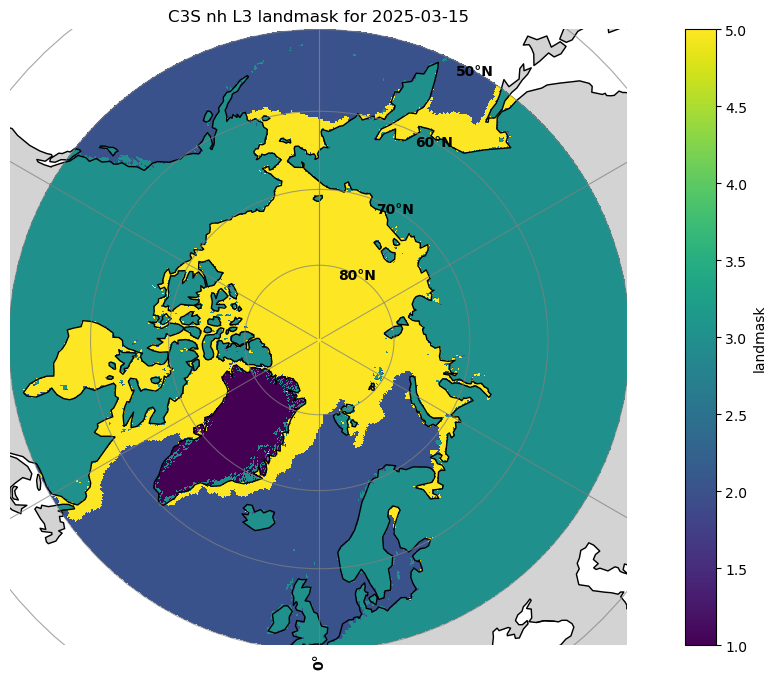

##### BASIC STATISTICS FOR landmask ######

Mean value: 3.58 

Median value: 3.00 

Standard deviation: 1.29 

Maximum value: 5.00 

Minimum value: 1.00 



In [12]:
# make geographical plots for a specfic date (e.g., 2025-08-01)
date = '2025-03-15'
if 'units' in ds.time.attrs:
    if np.logical_or(ds.time.attrs['units'] == 'μs',ds.time.attrs['units'] == 'ms'):
        file_dates = np.array([datetime.fromordinal(int((val/(1000000*60*60*24))+datetime.toordinal(datetime(1970,1,1)))) for val in ds.time.values])
    else:
        file_dates = np.array([datetime.fromordinal(int((val/(60*60*24))+datetime.toordinal(datetime(1962,1,1)))) for val in ds.time.values])
else:
    file_dates = np.array([datetime.strptime(str((val)), '%Y-%m-%dT00:00:00.000000000') - relativedelta(years=16) for val in ds.time.values])
#file_dates
date_idx = np.where(file_dates == datetime.strptime(date, '%Y-%m-%d'))[0][0]

#Extracting the data for the specific date
ST_degc_date = ST_degc.isel(time=date_idx)
mask_date = mask.isel(time=date_idx)


# Sea and Sea-ice Surface temperature
varname = 'ST'
savename = f'{hem}_{varname}_{date}.png'
geographical_simple(ST_degc_date.values, varname, path_out, date, hem, savename)
basic_statistics(ST_degc_date, varname)

# Land, Ocean, Ice mask
varname = 'landmask'
savename = f'{hem}_{varname}_{date}.png'
geographical_simple(mask_date, varname, path_out, date, hem, savename)
basic_statistics(mask_date, varname)

## 2. Calculate climate normals

#### Standard reference period and climate normals

Anthropogenic activities and natural variations from years to decades shape the Earth's climate. In order to evaluate anomalous conditions of a specific month or year, the World Meteorological Organization (WMO) defines `standard reference periods` used to create `climate normals`. 
`Climate normals` can be considered as the typical climate for the period the normals are based on.

Until 2020, the most current and widely used standard reference period was the 30-year range of 1981-2010. With the start of 2021, the WMO recommended updating the climate normal reference period to the range 1991-2020, which is the reference period we will be using for this tutorial.

First, let us calculate the sea, sea-ice, and icecap surface temperature climate normal for the reference period.

The `Sea ice surface temperature derived from satellite observations` dataset on CDS already have monthly mean files.
We will collect these monthly files for the input year/years as well as the climate years (here we will do it for the Northern Hemisphere only in Step 2.0), subsequently in Step 2.1 these files are used as the climatology to compute the monthly anomalies for the year of 2025.

As we want the reference period files as well as the 2025 data, we will make two requests. This step will need a slot of storage space, and will also take a long time to run as we need to download a lot of data.

The naming convention for the monthly files are
* yyyymm-DMI_MET-L3S_GHRSST-STskin-AVHRR_nh_SST_IST-MM_CDR-v1.0-fv1.0.nc for CDR (1982-2019, *nh* can be changed to *sh* for southern hemispheric data)

* yyyymm-DMI_MET-L3S_GHRSST-STskin-AVHRR_nh_SST_IST-MM_ICDR-v1.1-fv1.0.nc for ICDR (2019-Now, *nh* can be changed to *sh* for southern hemispheric data)

**Be aware, that the steps 2.0 and 2.1 is only to be done once, as they will save a climatology file for the climatological period 1991-2020. Meaning that once this file is saved, it can be used for computing anomalies in step 3 and onward.**

 **Step 2.0:**  Request/Download monthly mean files.

In [13]:
dataset = "satellite-ist-sst-polar"
request1 = {
    "variable": "all",
    "region": [hemisphere],
    "temporal_aggregation": "monthly",
    "year": [
        "1991", "1992", "1993",
        "1994", "1995", "1996",
        "1997", "1998", "1999",
        "2000", "2001", "2002",
        "2003", "2004", "2005",
        "2006", "2007", "2008",
        "2009", "2010", "2011",
        "2012", "2013", "2014",
        "2015", "2016", "2017",
        "2018", "2019", "2020"
    ],
    "month": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12"
    ],
    "version": [
        "1_0",
        "1_1"
    ]
}
target_file1 = f'{DATADIR}/clim/{hem}_clim_temp.zip' #This is the path to the zip file containing the downloaded data. Remember to change this name if you repeatedly downloaded the data and have multiple zip files. You can also change the name of the zip file to something more descriptive. If the filename is not changed, previous downloads will be overwritten.
client = cdsapi.Client()
client.retrieve(dataset, request1, target_file1)

# Unpack the climate normal temp.zip
with ZipFile(f"{target_file1}", 'r') as zObject:
    # Extracting all the members of the zip into a specific location.
    zObject.extractall(
        path=f"{DATADIR}/clim/")
    

2026-08-17 09:34:30,693 INFO Request ID is 88b2e18c-4f37-40f0-a391-83326cb669e4
2026-08-17 09:34:30,784 INFO status has been updated to accepted
2026-08-17 09:35:08,604 INFO status has been updated to running
2026-08-17 09:35:26,305 INFO status has been updated to successful


**Step 2.1:** Combine monthly composites to compute the climatology 1991-2020

In [14]:
path = f'{DATADIR}/clim/' # path to save climatology to and get monthly files from

# Get all the files
print(f'Getting filenames ({hem})...')
files = np.sort(glob.glob(f'{path}*{hem}*-MM*.nc'))

# Load all 1991-2020 monthly mean climatologies
print(f'Loading monthly files for 1991-2020 ({hem})...')
data = xr.open_mfdataset(files, concat_dim='time', combine='nested')

# Calculate the mean of all same months in each gridpoint
print(f'Computing 1991-2020 climatology ({hem})...')
data_clim = data.groupby('time.month').mean(dim='time')
data_clim_y = data.mean(dim='time', skipna=True)


#Add the climatology field as well (mean of full period)
data_clim['surface_temperature_clim'] = data_clim_y['surface_temperature']
data_clim['N_clim'] = data_clim_y['N']
data_clim['t2m_clim'] = data_clim_y['t2m']
data_clim['surface_temperature_min_clim'] = data_clim_y['surface_temperature_min']
data_clim['surface_temperature_max_clim'] = data_clim_y['surface_temperature_max']
data_clim['sea_ice_fraction_clim'] = data_clim_y['sea_ice_fraction']
data_clim['surface_type_clim'] = data_clim_y['surface_type']

#Change the name of the time dimension to "time" instead of "month"
data_clim = data_clim.rename({'month': 'time'})


# Save to netcdf file
print(f'Saving to file ({hem})...')
data_clim.to_netcdf(f"{path}{hem}_CLIM_1991_2020.nc")
print('Done!')

Getting filenames (nh)...
Loading monthly files for 1991-2020 (nh)...
Computing 1991-2020 climatology (nh)...
Saving to file (nh)...
Done!


## 3. Anomaly calculation

The next step is now to calculate the anomaly of a specific year with respect to the climate normal. The term anomaly refers to the deviation of a value from the long-term average. Positive or negative anomalies indicate that the average temperatures of a particular year were respectively warmer or cooler than the reference value.

Let us calculate the sea and sea-ice surface temperature anomaly for the year 2025.


**Step 3.1**: Create yearly composites

In [15]:
# define year and download monthly files for that year
year = 2025
if year >= 2020:
    version = "1_1"
else:
    version = "1_0"
    
print(f'Working on year {str(year)} ({hem})')
print('--------------------')
path_in  = f'{DATADIR}/monthly/'
path_out = f'{DATADIR}/annual/' # one file per year (dimension 365/366 days X lat,lon)

request1 = {
    "variable": "all",
    "region": [hemisphere],
    "temporal_aggregation": "monthly",
    "year": [str(year)],
    "month": ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10", "11", "12"],
    "version": [version]
}
##!!magnus line:: target_file1 = f'{DATADIR}/monthly/temp.zip' #This is the path to the zip file containing the downloaded data. Remember to change this name if you repeatedly downloaded the data and have multiple zip files. You can also change the name of the zip file to something more descriptive. If the filename is not changed, previous downloads will be overwritten.
target_file1 = f'{DATADIR}/clim/temp.zip' #This is the path to the zip file containing the downloaded data. Remember to change this name if you repeatedly downloaded the data and have multiple zip files. You can also change the name of the zip file to something more descriptive. If the filename is not changed, previous downloads will be overwritten.
client = cdsapi.Client()
client.retrieve(dataset, request1, target_file1)

# CHECK!! /dmidata/users/gd/c3s_ur_testdata/data/clim/nh_clim_temp.zip NOT temp zip...

# Unpack the year temp.zip
with ZipFile(f"{target_file1}", 'r') as zObject:
    # Extracting all the members of the zip into a specific location.
    zObject.extractall(
        path=f"{DATADIR}/monthly/")
   

# Get all the L3 files for the year
pattern = f'{str(year)}*L3S*{hem}*.nc'
filelist = []
print('Getting filenames...')
for (root, dirs, files) in os.walk(path_in):#, topdown=False):
    for name in files:
        if fnmatch(name, pattern):
           filelist.append(path_in + name)
filelist = sorted(filelist)
print('Done!')

# Open all the files together with xarray's mfdataset
print('Loading files...')
data = xr.open_mfdataset(filelist,concat_dim='time',compat='broadcast_equals',join='override', combine='nested')
print('Files loaded')


# Modify file global attributes
data.attrs['stop_time'] = str(year)+'1231T235959Z'
data.attrs['time_coverage_end'] = str(year)+'1231T235959Z'
data.attrs['date_created'] = datetime.now().strftime('%Y%m%dT%H%M%SZ')
# data.attrs['spatial_resolution'] = '0.05 degrees'

# Compute annual mean fields
data_y = data.mean(dim='time', skipna=True)

#And add the yearly means as variables to the dataset
data['surface_temperature_YY'] = data_y['surface_temperature']
data['N_YY'] = data_y['N']
data['t2m_YY'] = data_y['t2m']
data['surface_temperature_min_YY'] = data_y['surface_temperature_min']
data['surface_temperature_max_YY'] = data_y['surface_temperature_max']
data['sea_ice_fraction_YY'] = data_y['sea_ice_fraction']
data['surface_type_YY'] = data_y['surface_type']

if not os.path.exists(path_out):
    os.makedirs(path_out)

# Set output file name
if year>=2019:
    file_out = f'{path_out}{str(year)}-DMI_MET-L3S_GHRSST-STskin-AVHRR_{hem}_SST_IST-YY_ICDR-v1.1-fv1.0.nc'
else:
    file_out = f'{path_out}{str(year)}-DMI_MET-L3S_GHRSST-STskin-AVHRR_{hem}_SST_IST-YY_CDR-v1.0-fv1.0.nc'
# Delete old file if already exists
if os.path.exists(file_out):
    os.remove(file_out)

# Save regridded dataset to netCDF file
print('Saving annual data to netCDF file...')
data.to_netcdf(file_out)
print(f'NetCDF file for {hem}, {year} created!')


Working on year 2025 (nh)
--------------------


2026-08-17 09:40:04,434 INFO Request ID is 0e9a347b-5a6f-4e6e-a610-f1fc7af044bf
2026-08-17 09:40:04,540 INFO status has been updated to accepted
2026-08-17 09:40:37,296 INFO status has been updated to running
2026-08-17 09:40:54,472 INFO status has been updated to successful


Getting filenames...
Done!
Loading files...
Files loaded
Saving annual data to netCDF file...
NetCDF file for nh, 2025 created!


**Step 3.2**: Compute anomaly and vizualise

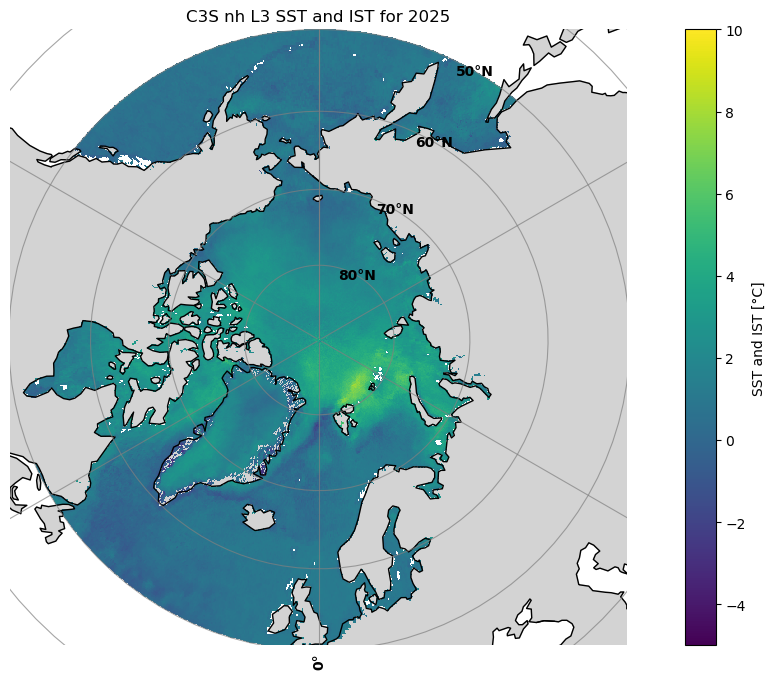

In [ ]:
path_out = f'{BASEPATH}/figures'

# Define year to examine
#year = 2025

# Read annual file
if year>=2019:
    ds = xr.open_dataset(f'{DATADIR}/annual/{str(year)}-DMI_MET-L3S_GHRSST-STskin-AVHRR_{hem}_SST_IST-YY_ICDR-v1.1-fv1.0.nc')
else:
    ds = xr.open_dataset(f'{DATADIR}/annual/{str(year)}-DMI_MET-L3S_GHRSST-STskin-AVHRR_{hem}_SST_IST-YY_CDR-v1.0-fv1.0.nc')

# load data and climatology
st_yyyy = ds['surface_temperature_YY']
st_1991_2020 = xr.open_dataset(f'{DATADIR}/clim/{hem}_CLIM_1991_2020.nc') #np.load(BASEPATH + '/gbl_monthly_mean_climatology/GBL_ST_CLIM_1991_2020.npy')

# compute anomalysh
st_yma = st_yyyy - st_1991_2020.surface_temperature_clim

lon = ds['lon'].values
lat = ds['lat'].values
# Create map
# ----------
varname = 'ST'
savename = f'{hem}_annual_mean_ST_anom_{year}.png'
# PLOT ANOMALY
geographical_simple(st_yma.values, varname, path_out, year, hem, savename)


In [20]:
# Calculate statistics
# --------------------

# Filter out outliers in the whole region
# med = np.nanmedian(sst_yma)
# mad = stats.median_abs_deviation(sst_yma,axis=None,nan_policy='omit')
# sst_yma[sst_yma <= med - 3*mad] = np.nan
# sst_yma[sst_yma >= med + 3*mad] = np.nan

# Stats for the whole region
st_yma_full_mean = np.nanmean(st_yma)
st_yma_full_std = np.nanstd(st_yma)

print(f'Full region, mean difference to climatology: {st_yma_full_mean:.2f} ± {st_yma_full_std:.2f} [°C]')

if hem == 'nh':
    # Stats for the Arctic region (north of 66.6° latitude)
    st_yma_full_mean = np.nanmean(st_yma[66:,:])
    st_yma_full_std = np.nanstd(st_yma[66:,:])

    print(f'Arctic region (north of 66.6° latitude), mean difference to climatology: {st_yma_full_mean:.2f} ± {st_yma_full_std:.2f} [°C]')
elif hem == 'sh':
    # Stats for the Antarctic region (south of 60° latitude)
    st_yma_full_mean = np.nanmean(st_yma[:120,:])
    st_yma_full_std = np.nanstd(st_yma[:120,:])

    print(f'Antarctic region (South of -60°), mean difference to climatology: {st_yma_full_mean:.2f} ± {st_yma_full_std:.2f} [°C]')


Full region, mean difference to climatology: 2.12 ± 1.35 [°C]
Arctic region (north of 66.6° latitude), mean difference to climatology: 2.54 ± 1.26 [°C]


**Monthly mean anomalies**
Let us take a look at the monthly anomalies for the year of 2025 - remember if you want to look at a year for which you have not downloaded the data yet, use **"Step 3.1: Create yearly composites"** above to dowload monthly data and compute the yearly composite file for the year in question - remember to change the **year** variable in that cell. For now we will look at 2025, where the data is already downloaded.

In [21]:
def timeseries_simple(st_mma,hem,year,path_out,savename):
    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(range(1, 13), st_mma, marker='o', color='b', linewidth=1)

    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
    ax.set_ylabel('Temperature anomaly (°C)')
    ax.set_title(f'Monthly mean anomalies {year}. For {hem.upper()}')
    ax.grid()
    plt.tight_layout()
    plt.savefig(f'{path_out}/{savename}', bbox_inches='tight')
    plt.show()

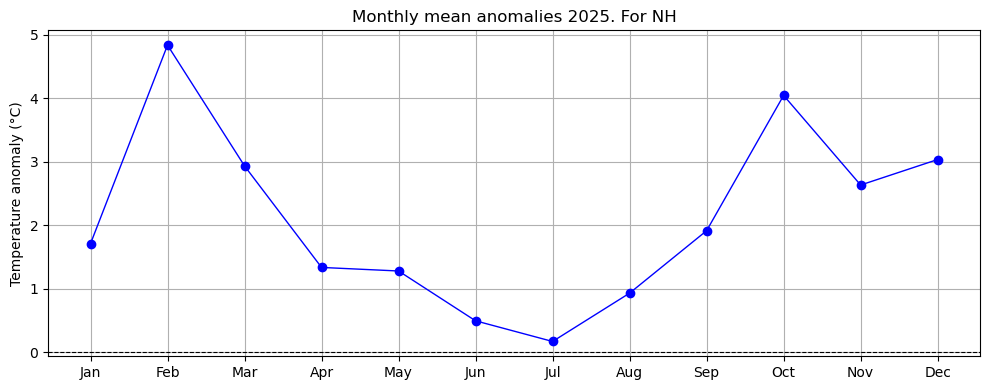

In [22]:
## Compute monthly mean anomalies and visualise 
# Define year to examine
path = f'{DATADIR}/clim/' # path to save climatology to and get monthly files from

# Read annual file
if year>=2019:
    ds = xr.open_dataset(f'{DATADIR}/annual/{str(year)}-DMI_MET-L3S_GHRSST-STskin-AVHRR_{hem}_SST_IST-YY_ICDR-v1.1-fv1.0.nc')
else:
    ds = xr.open_dataset(f'{DATADIR}/annual/{str(year)}-DMI_MET-L3S_GHRSST-STskin-AVHRR_{hem}_SST_IST-YY_CDR-v1.0-fv1.0.nc')

# Read clim file
ds_clim = xr.open_dataset(f"{path}{hem}_CLIM_1991_2020.nc")

# compute monthly anomaly fields
st_ma = ds['surface_temperature'].values - ds_clim['surface_temperature'].values

# Compute monthly mean anomalies
st_mma = np.nanmean(st_ma,axis=(1,2))

# Plot monthly mean anomalies timeseries
savename = f'{hem}_monthly_mean_ST_anom_{year}.png'
timeseries_simple(st_mma,hem,year,path_out,savename)